<a href="https://colab.research.google.com/github/mikecrv2019-bit/MAESTRIA-IA/blob/main/Herramienta_Regresion_CO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/mikecrv2019-bit/MAESTRIA-IA/blob/main/MAI540_Modulo%204_Tarea%204.2_Herramienta%20de%20Regresi%C3%B3n%20Auditada/Herramienta_Regresion_CO2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Herramienta de Regresión Auditada — Emisiones de CO₂ de vehículos

**MAI 540 — Machine Learning | Módulo 4 | Tarea 4.2**

La herramienta estima las emisiones de CO₂ (g/km) de una configuración de vehículo ligero a partir de sus especificaciones técnicas. Apoya esta decisión: antes de la homologación oficial, un fabricante o importador decide si la configuración cumple el límite de emisiones de su flota. El error se expresa en **g/km**.

Las reglas de datos (variables prohibidas, partición, subgrupos) están en `context.md`, en esta misma carpeta.

## Decisiones del plan (paso 2)

| Decisión | Valor | Quién la tomó |
|---|---|---|
| Variables prohibidas por fuga | `Fuel Consumption Comb (L/100 km)`, `Comb (mpg)`, `City (L/100 km)`, `Hwy (L/100 km)` | Usuario (Comb y mpg en el paso 1; City y Hwy en el paso 2) |
| Variables excluidas | `Make`, `Model` | Usuario |
| Duplicados exactos | Se eliminan antes de la partición (7.385 → 6.282 filas) | Usuario |
| Partición | 75/25, `random_state=42`, estratificada por `Fuel Type` | Propuesta de Claude, aprobada por el usuario |
| Fila de gas natural (N, 1 fila) | Se conserva y va solo al entrenamiento; en prueba es "no evaluable" | Usuario |
| Imputación | Mediana (numéricas) y moda (categóricas). Hoy no hay nulos; los imputadores protegen ante datos nuevos | Claude |
| Codificación | `OneHotEncoder(handle_unknown="ignore")`; `Transmission` se codifica tal cual (27 valores) | Claude |
| Escalado | `StandardScaler` en las numéricas | Claude |
| Segundo modelo | `RandomForestRegressor(n_estimators=300, random_state=42)`; el resto por defecto, sin ajustar con el conjunto de prueba | Claude |

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from urllib.parse import quote

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

RANDOM_STATE = 42
TARGET = "CO2 Emissions(g/km)"
SUBGRUPO = "Fuel Type"
PROHIBIDAS = [
    "Fuel Consumption Comb (L/100 km)",   # fuga: el CO2 se calcula a partir de este consumo
    "Fuel Consumption Comb (mpg)",        # fuga: la misma medida en otra unidad
    "Fuel Consumption City (L/100 km)",   # fuga: misma prueba de consumo que el CO2
    "Fuel Consumption Hwy (L/100 km)",    # fuga: misma prueba de consumo que el CO2
]
EXCLUIDAS = ["Make", "Model"]
NUMERICAS = ["Engine Size(L)", "Cylinders"]
CATEGORICAS = ["Vehicle Class", "Transmission", "Fuel Type"]

## 1. Carga de datos (solo lectura)

Si el CSV está junto al cuaderno (repositorio clonado), se lee de `data/raw/`. En Google Colab se descarga desde el repositorio en GitHub.

In [ ]:
RUTA_LOCAL = Path("data/raw/CO2 Emissions_Canada.csv")
URL_GITHUB = ("https://raw.githubusercontent.com/mikecrv2019-bit/MAESTRIA-IA/main/"
              + quote("MAI540_Modulo 4_Tarea 4.2_Herramienta de Regresión Auditada")
              + "/data/raw/" + quote("CO2 Emissions_Canada.csv"))

fuente = RUTA_LOCAL if RUTA_LOCAL.exists() else URL_GITHUB
df_raw = pd.read_csv(fuente)
print("Fuente:", fuente)
print("Filas y columnas:", df_raw.shape)
assert df_raw.shape == (7385, 12), "El CSV no es el esperado"
df_raw.head()

Fuente: data\raw\CO2 Emissions_Canada.csv
Filas y columnas: (7385, 12)


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## 2. Eliminación de duplicados exactos

Se eliminan las filas idénticas en las 12 columnas originales, **antes** de la partición. Así la misma fila no puede quedar a la vez en entrenamiento y en prueba. No es una transformación que estime parámetros: no genera fuga.

In [ ]:
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Duplicados exactos eliminados:", len(df_raw) - len(df))
print("Filas restantes:", len(df))
assert len(df) == 6282
df[SUBGRUPO].value_counts()

Duplicados exactos eliminados: 1103
Filas restantes: 6282


Fuel Type
X    3039
Z    2765
E     330
D     147
N       1
Name: count, dtype: int64

## 3. Eliminación de variables prohibidas y excluidas; separación de la objetivo

In [ ]:
X = df.drop(columns=PROHIBIDAS + EXCLUIDAS + [TARGET])
y = df[TARGET]

assert not set(PROHIBIDAS + EXCLUIDAS) & set(X.columns), "Quedó una variable prohibida o excluida"
assert set(X.columns) == set(NUMERICAS + CATEGORICAS)
print("Predictoras:", list(X.columns))
print("Nulos en X:", int(X.isna().sum().sum()), "| Nulos en y:", int(y.isna().sum()))

Predictoras: ['Vehicle Class', 'Engine Size(L)', 'Cylinders', 'Transmission', 'Fuel Type']
Nulos en X: 0 | Nulos en y: 0


## 4. Partición entrenamiento / prueba (una sola, para los tres modelos)

Se estratifica por `Fuel Type` con las filas X, Z, E y D. La fila de gas natural (N) no se puede estratificar porque es una sola, así que se agrega solo al entrenamiento.

In [ ]:
es_n = X[SUBGRUPO] == "N"
X_train, X_test, y_train, y_test = train_test_split(
    X[~es_n], y[~es_n], test_size=0.25, random_state=RANDOM_STATE, stratify=X.loc[~es_n, SUBGRUPO]
)
X_train = pd.concat([X_train, X[es_n]])
y_train = pd.concat([y_train, y[es_n]])

assert X_train.index.intersection(X_test.index).empty, "Hay filas compartidas entre entrenamiento y prueba"
assert len(X_train) + len(X_test) == len(X)
assert (X_test[SUBGRUPO] != "N").all()
print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
pd.DataFrame({"entrenamiento": X_train[SUBGRUPO].value_counts(),
              "prueba": X_test[SUBGRUPO].value_counts()}).fillna(0).astype(int)

Entrenamiento: (4711, 5) | Prueba: (1571, 5)


,entrenamiento,prueba
Fuel Type,,
D,110,37
E,248,82
N,1,0
X,2279,760
Z,2073,692


## 5. Preprocesamiento dentro de un Pipeline

Imputación, codificación y escalado viven en un `ColumnTransformer` dentro de cada `Pipeline`. Por eso sus parámetros (medianas, modas, categorías, medias y desviaciones) se estiman solo cuando el pipeline se ajusta con el conjunto de entrenamiento.

In [ ]:
def crear_preprocesador():
    numerico = Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ])
    categorico = Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("codificar", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", numerico, NUMERICAS),
        ("cat", categorico, CATEGORICAS),
    ])

## 6. Entrenamiento de los tres modelos

Los tres usan el mismo preprocesamiento y la misma partición:

- **(a) Referencia trivial:** `DummyRegressor` que siempre predice la media del entrenamiento.
- **(b) Regresión lineal.**
- **(c) Random Forest Regressor:** capta interacciones no lineales (por ejemplo, tipo de combustible × cilindrada) que la regresión lineal no representa, y no depende del escalado.

In [ ]:
modelos = {
    "Referencia (media)": DummyRegressor(strategy="mean"),
    "Regresión lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
}

pipelines, pred_train, pred_test = {}, {}, {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", crear_preprocesador()), ("modelo", modelo)])
    pipe.fit(X_train, y_train)          # ajuste SOLO con entrenamiento
    pipelines[nombre] = pipe
    pred_train[nombre] = pipe.predict(X_train)
    pred_test[nombre] = pipe.predict(X_test)  # prueba: solo transformar y predecir
    print(f"{nombre}: entrenado")

Referencia (media): entrenado
Regresión lineal: entrenado


Random Forest: entrenado


### Verificaciones del ajuste sin fuga

In [ ]:
# El escalador aprendió la media del ENTRENAMIENTO, no la del dataset completo
escalador = pipelines["Regresión lineal"].named_steps["prep"].named_transformers_["num"].named_steps["escalar"]
assert np.allclose(escalador.mean_, X_train[NUMERICAS].mean().values)
print("Media aprendida por el escalador:", escalador.mean_.round(4))
print("Media del entrenamiento:         ", X_train[NUMERICAS].mean().values.round(4))
print("Media del dataset completo:      ", X[NUMERICAS].mean().values.round(4))

# El modelo de referencia predice siempre la media del entrenamiento
assert np.allclose(pred_test["Referencia (media)"], y_train.mean())
print("Predicción constante de la referencia:", round(y_train.mean(), 2), "g/km")

for nombre in modelos:
    assert len(pred_test[nombre]) == len(y_test)
print("Predicciones de prueba por modelo:", {k: len(v) for k, v in pred_test.items()})

Media aprendida por el escalador: [3.1562 5.6101]
Media del entrenamiento:          [3.1562 5.6101]
Media del dataset completo:       [3.1618 5.6189]
Predicción constante de la referencia: 250.79 g/km
Predicciones de prueba por modelo: {'Referencia (media)': 1571, 'Regresión lineal': 1571, 'Random Forest': 1571}


## 7. Métricas de los tres modelos (paso 3)

MSE, RMSE y R² sobre el **conjunto de prueba**, que se usa aquí por primera vez. El MSE está en (g/km)² y el RMSE en g/km.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

filas = []
for nombre in modelos:
    mse_te = mean_squared_error(y_test, pred_test[nombre])
    filas.append({
        "Modelo": nombre,
        "MSE prueba (g/km)²": mse_te,
        "RMSE prueba (g/km)": np.sqrt(mse_te),
        "R² prueba": r2_score(y_test, pred_test[nombre]),
        "RMSE entrenamiento (g/km)": np.sqrt(mean_squared_error(y_train, pred_train[nombre])),
        "R² entrenamiento": r2_score(y_train, pred_train[nombre]),
    })
tabla = pd.DataFrame(filas).set_index("Modelo")

# RMSE recalculado a mano desde los residuos, como verificación
for nombre in modelos:
    rmse_manual = np.sqrt(np.mean((y_test.values - pred_test[nombre]) ** 2))
    assert np.isclose(rmse_manual, tabla.loc[nombre, "RMSE prueba (g/km)"])

tabla.round(4)

,MSE prueba (g/km)²,RMSE prueba (g/km),R² prueba,RMSE entrenamiento (g/km),R² entrenamiento
Modelo,,,,,
Referencia (media),3545.1566,59.5412,-0.0006,59.2018,0.0000
Regresión lineal,496.5584,22.2836,0.8598,22.4589,0.8561
Random Forest,236.0910,15.3653,0.9334,12.9844,0.9519


In [ ]:
rmse_ref = tabla.loc["Referencia (media)", "RMSE prueba (g/km)"]
comparacion = pd.DataFrame({
    "RMSE prueba (g/km)": tabla["RMSE prueba (g/km)"],
    "Reducción vs referencia (g/km)": rmse_ref - tabla["RMSE prueba (g/km)"],
    "Reducción vs referencia (%)": 100 * (1 - tabla["RMSE prueba (g/km)"] / rmse_ref),
    "R² entrenamiento − R² prueba": tabla["R² entrenamiento"] - tabla["R² prueba"],
})
print("Contexto del conjunto de prueba:")
print(f"  CO2 medio = {y_test.mean():.2f} g/km | desviación estándar = {y_test.std(ddof=0):.2f} g/km")
print(f"  mínimo = {y_test.min()} | máximo = {y_test.max()} g/km")
comparacion.round(4)

Contexto del conjunto de prueba:
  CO2 medio = 252.26 g/km | desviación estándar = 59.52 g/km
  mínimo = 96 | máximo = 522 g/km


,RMSE prueba (g/km),Reducción vs referencia (g/km),Reducción vs referencia (%),R² entrenamiento − R² prueba
Modelo,,,,
Referencia (media),59.5412,0.0000,0.0000,0.0006
Regresión lineal,22.2836,37.2576,62.5745,-0.0038
Random Forest,15.3653,44.1760,74.1939,0.0185


### Interpretación de las métricas

| Modelo | MSE prueba (g/km)² | RMSE prueba (g/km) | R² prueba | R² entrenamiento |
|---|---|---|---|---|
| Referencia (media) | 3.545,16 | 59,54 | −0,0006 | 0,0000 |
| Regresión lineal | 496,56 | 22,28 | 0,8598 | 0,8561 |
| Random Forest | 236,09 | 15,37 | 0,9334 | 0,9519 |

**Qué significa el RMSE en unidades reales.** El mejor modelo, Random Forest, tiene un RMSE de 15,37 g/km. Al estimar el CO₂ de una configuración nueva, el error típico es de unos 15 g/km, sobre un CO₂ medio de 252,26 g/km en prueba (≈ 6,1 %). El RMSE no es un tope: al elevar los errores al cuadrado, pesa más los errores grandes, así que algunos vehículos tendrán desviaciones mayores. Para la decisión de homologación, una configuración cuya estimación quede a menos de unos 15 g/km del límite de la flota no se puede clasificar con seguridad como "cumple" o "no cumple". La regresión lineal tiene un error típico de 22,28 g/km (≈ 8,8 %).

**Qué proporción de la variación explica el R².** Con un R² de prueba de 0,9334, Random Forest explica el 93,3 % de la variación del CO₂ entre vehículos del conjunto de prueba. El 6,7 % restante lo explican factores que no están en las cinco especificaciones usadas (por ejemplo, aerodinámica, peso o tecnología del motor) o que son ruido de la medición. La regresión lineal explica el 86,0 %.

**Por qué no basta con una sola métrica.**
- El R² es relativo y sin unidades: compara el error del modelo con la dispersión del CO₂ en el conjunto de prueba. No dice si 15 g/km es un error aceptable para decidir sobre un límite de emisiones; eso solo lo dice el RMSE, en g/km.
- El RMSE solo, sin referencia, no dice si el modelo aprendió algo. La referencia trivial tiene un RMSE de 59,54 g/km, que parece moderado frente a una media de 252 g/km (≈ 24 %), y sin embargo su R² ≈ 0 muestra que no explica nada: su error es exactamente la dispersión natural del CO₂ (desviación estándar de prueba: 59,52 g/km).
- Un mismo RMSE puede ser excelente en un conjunto muy disperso y malo en uno homogéneo. Un R² alto también puede venir con un RMSE demasiado grande para la decisión. Juntas responden dos preguntas distintas: cuánto se equivoca el modelo (RMSE) y cuánto de la variación captura (R²).

**Mejora frente a la referencia trivial.** La referencia siempre predice 250,79 g/km, la media del entrenamiento. Su R² de prueba es ligeramente negativo (−0,0006) porque la media de prueba (252,26) no coincide exactamente con esa cifra.
- La regresión lineal reduce el RMSE en 37,26 g/km (−62,6 %).
- Random Forest lo reduce en 44,18 g/km (−74,2 %).
- Frente a la regresión lineal, Random Forest baja el error típico 6,92 g/km más (≈ 31 % menos).

**Sobreajuste: R² de entrenamiento frente a prueba.**
- **Regresión lineal:** 0,8561 en entrenamiento y 0,8598 en prueba (diferencia −0,0038; RMSE 22,46 frente a 22,28 g/km). No hay sobreajuste: rinde igual en datos que no vio. Su límite es la capacidad del modelo, que no representa relaciones no lineales, no la memorización.
- **Random Forest:** 0,9519 en entrenamiento y 0,9334 en prueba (diferencia 0,0185; RMSE 12,98 frente a 15,37 g/km). Hay una brecha pequeña: el bosque ajusta algo mejor los datos que vio, pero la caída en prueba es menor de 2 puntos de R², y aun así supera claramente a la regresión lineal en datos no vistos. No se ajustaron hiperparámetros con el conjunto de prueba, así que estas cifras son una estimación no sesgada de su desempeño.

Random Forest es el mejor modelo y es el que se analiza en el paso 4 (residuos).

## 8. Análisis de residuos del mejor modelo: Random Forest (paso 4)

Residuo = CO₂ real − CO₂ predicho, sobre el conjunto de prueba. Un residuo **positivo** significa que el modelo **subestima** las emisiones; uno negativo, que las sobreestima. Las figuras se guardan en `figuras/` para el informe.

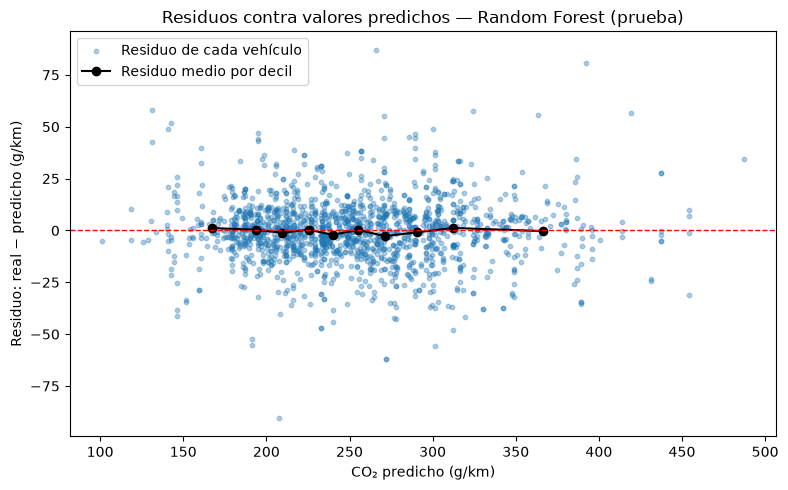

In [ ]:
import matplotlib.pyplot as plt

MEJOR = "Random Forest"
pred = pd.Series(pred_test[MEJOR], index=y_test.index, name="predicho")
res = (y_test - pred).rename("residuo")
Path("figuras").mkdir(exist_ok=True)

# Media y desviación de los residuos por decil del valor predicho (línea de tendencia)
decil = pd.qcut(pred, 10)
por_decil = pd.DataFrame({"pred": pred, "res": res}).groupby(decil, observed=True).agg(
    pred_medio=("pred", "mean"), res_medio=("res", "mean"), res_desv=("res", "std"), n=("res", "size"))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pred, res, s=10, alpha=0.35, label="Residuo de cada vehículo")
ax.plot(por_decil["pred_medio"], por_decil["res_medio"], "o-", color="black", label="Residuo medio por decil")
ax.axhline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("CO₂ predicho (g/km)")
ax.set_ylabel("Residuo: real − predicho (g/km)")
ax.set_title("Residuos contra valores predichos — Random Forest (prueba)")
ax.legend()
fig.tight_layout()
fig.savefig("figuras/residuos_vs_predichos.png", dpi=150)
plt.show()

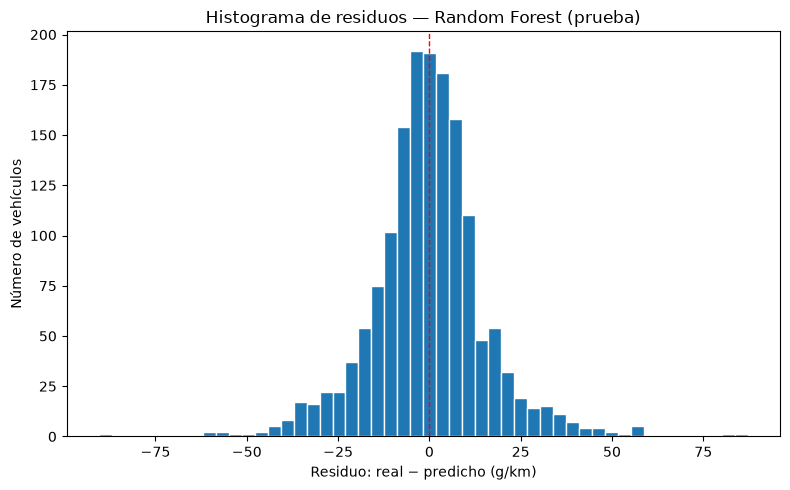

Media = -0.37 | mediana = -0.04 | desviación = 15.37 g/km
Asimetría = 0.10 | curtosis (exceso) = 3.15
|residuo| > 30 g/km: 108 vehículos (6.9 %)
Percentiles 1, 5, 95 y 99: {0.01: -38.2, 0.05: -26.1, 0.95: 23.9, 0.99: 43.2}


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(res, bins=50, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Residuo: real − predicho (g/km)")
ax.set_ylabel("Número de vehículos")
ax.set_title("Histograma de residuos — Random Forest (prueba)")
fig.tight_layout()
fig.savefig("figuras/histograma_residuos.png", dpi=150)
plt.show()

print(f"Media = {res.mean():.2f} | mediana = {res.median():.2f} | desviación = {res.std():.2f} g/km")
print(f"Asimetría = {res.skew():.2f} | curtosis (exceso) = {res.kurt():.2f}")
print(f"|residuo| > 30 g/km: {(res.abs() > 30).sum()} vehículos ({100 * (res.abs() > 30).mean():.1f} %)")
print("Percentiles 1, 5, 95 y 99:", res.quantile([.01, .05, .95, .99]).round(1).to_dict())

### Evidencia numérica: curvatura y dispersión por decil del valor predicho

In [ ]:
por_decil.round(2)

,pred_medio,res_medio,res_desv,n
predicho,,,,
"(100.96499999999999, 186.28]",167.27,1.17,15.17,164
"(186.28, 201.012]",193.71,0.36,13.66,151
"(201.012, 216.097]",209.60,-1.12,14.61,161
"(216.097, 233.264]",225.34,0.35,14.66,162
"(233.264, 248.373]",239.91,-2.07,11.84,152
"(248.373, 262.403]",255.34,0.22,13.04,154
"(262.403, 278.796]",271.37,-2.72,18.62,156
"(278.796, 300.132]",290.70,-0.89,15.81,159
"(300.132, 326.647]",312.34,1.22,17.28,161


### Evidencia numérica: ¿hay grupos con residuos sistemáticamente positivos o negativos?

In [ ]:
def resumen_por(columna):
    g = pd.DataFrame({"res": res, columna: X_test[columna]}).groupby(columna)["res"]
    t = pd.DataFrame({"n": g.size(), "residuo_medio": g.mean(), "residuo_mediano": g.median(),
                      "RMSE": g.apply(lambda r: np.sqrt(np.mean(r ** 2)))})
    # t = media / error estándar: |t| > 2 indica un sesgo difícil de atribuir al azar
    t["t"] = t["residuo_medio"] / (g.std() / np.sqrt(g.size()))
    return t.sort_values("residuo_medio")

print("Por tipo de combustible:")
display(resumen_por("Fuel Type").round(2))
print("Por clase de vehículo:")
display(resumen_por("Vehicle Class").round(2))

Por tipo de combustible:


,n,residuo_medio,residuo_mediano,RMSE,t
Fuel Type,,,,,
D,37,-2.86,-3.46,19.06,-0.91
E,82,-1.85,-1.51,11.80,-1.43
Z,692,-0.65,-0.12,15.64,-1.09
X,760,0.17,0.24,15.25,0.31


Por clase de vehículo:


,n,residuo_medio,residuo_mediano,RMSE,t
Vehicle Class,,,,,
MINIVAN,14,-5.60,-5.95,10.32,-2.33
SPECIAL PURPOSE VEHICLE,18,-2.40,-2.68,7.04,-1.50
SUV - SMALL,266,-1.92,-1.91,16.87,-1.86
MINICOMPACT,72,-1.66,-2.74,10.78,-1.31
FULL-SIZE,115,-1.59,-0.15,15.31,-1.11
VAN - CARGO,6,-1.18,2.11,6.39,-0.42
COMPACT,209,-1.01,-1.22,13.86,-1.05
SUBCOMPACT,133,-0.32,0.30,13.25,-0.28
PICKUP TRUCK - STANDARD,132,-0.26,1.35,15.25,-0.20


In [ ]:
# Los 10 residuos más grandes en valor absoluto (solo especificaciones, sin Make/Model)
extremos = X_test.assign(real=y_test, predicho=pred.round(1), residuo=res.round(1)) \
    .reindex(res.abs().sort_values(ascending=False).index).head(10)
extremos

,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,real,predicho,residuo
6070,FULL-SIZE,2.0,4,AM6,X,117,207.4,-90.4
3790,SUV - SMALL,3.0,6,A9,Z,353,265.9,87.1
4583,SUV - STANDARD,6.0,12,A7,Z,473,392.4,80.6
4788,SUV - SMALL,3.0,6,AM7,Z,210,271.7,-61.7
3104,SUV - SMALL,3.0,6,AM7,Z,210,271.7,-61.7
5905,MID-SIZE,1.5,4,AV,X,189,131.1,57.9
193,COMPACT,6.2,8,AS6,Z,382,324.4,57.6
2762,SUV - STANDARD,6.0,12,AS7,Z,476,419.4,56.6
1100,MID-SIZE,4.0,8,AS8,Z,246,301.6,-55.6
4582,SUV - STANDARD,5.5,8,A7,Z,419,363.5,55.5


### Diagnóstico: ¿qué estructura deja de capturar el modelo?

`Make` y `Model` están **excluidas del modelo**. Aquí solo se consultan, para buscar qué tienen en común los vehículos con residuos grandes. Los nombres comerciales indican tecnologías que las cinco especificaciones no registran: híbrido (`HYBRID`) y tracción integral (`AWD`, `4WD`, `4X4`).

In [ ]:
modelo_comercial = df.loc[y_test.index, "Model"].str.upper()
filas_tec = []
for etiqueta in ["HYBRID", "AWD", "4WD", "4X4"]:
    tiene = modelo_comercial.str.contains(etiqueta, regex=False)
    r = res[tiene]
    filas_tec.append({"En el nombre del modelo": etiqueta, "n (prueba)": int(tiene.sum()),
                      "residuo_medio": r.mean(), "residuo_mediano": r.median(),
                      "t": r.mean() / (r.std() / np.sqrt(len(r))),
                      "residuo_medio del resto": res[~tiene].mean()})
display(pd.DataFrame(filas_tec).set_index("En el nombre del modelo").round(2))
print("Los 10 residuos más grandes, con su nombre comercial:")
display(df.loc[extremos.index, ["Make", "Model"]].join(extremos[["real", "predicho", "residuo"]]))

,n (prueba),residuo_medio,residuo_mediano,t,residuo_medio del resto
En el nombre del modelo,,,,,
HYBRID,30,-24.15,-21.14,-5.98,0.10
AWD,241,4.33,5.38,4.80,-1.22
4WD,104,5.16,5.35,3.41,-0.76
4X4,74,8.00,8.24,5.08,-0.78


Los 10 residuos más grandes, con su nombre comercial:


,Make,Model,real,predicho,residuo
6070,HYUNDAI,Sonata Hybrid,117,207.4,-90.4
3790,MERCEDES-BENZ,AMG GLC 43 4MATIC COUPE,353,265.9,87.1
4583,MERCEDES-BENZ,AMG G 65,473,392.4,80.6
4788,ACURA,MDX Hybrid AWD,210,271.7,-61.7
3104,ACURA,MDX HYBRID AWD,210,271.7,-61.7
5905,CHEVROLET,Malibu,189,131.1,57.9
193,CHEVROLET,CAMARO ZL1,382,324.4,57.6
2762,MERCEDES-BENZ,AMG G 65,476,419.4,56.6
1100,AUDI,A8,246,301.6,-55.6
4582,MERCEDES-BENZ,AMG G 63,419,363.5,55.5


In [ ]:
# Vehículos distintos con las MISMAS cinco especificaciones: el modelo solo puede darles una predicción
combos = df.groupby(NUMERICAS + CATEGORICAS)[TARGET]
tam = combos.transform("size")
desvio = df[TARGET] - combos.transform("mean")
print(f"Combinaciones distintas de las 5 especificaciones: {combos.ngroups} (para {len(df)} filas)")
print(f"Filas que comparten combinación con otra fila: {(tam > 1).sum()}")
print(f"RMSE del CO2 alrededor de la media de su combinación: {np.sqrt(np.mean(desvio[tam > 1] ** 2)):.2f} g/km")

Combinaciones distintas de las 5 especificaciones: 964 (para 6282 filas)
Filas que comparten combinación con otra fila: 6102
RMSE del CO2 alrededor de la media de su combinación: 13.16 g/km


### Interpretación de los residuos

**1. Curvatura: no hay.** El residuo medio por decil del valor predicho va de −2,72 a +1,22 g/km, sin tendencia: sube y baja alrededor de cero en todo el rango (de 167 a 366 g/km predichos). Estas oscilaciones son pequeñas frente al RMSE de 15,37 g/km. En la gráfica, la línea negra se mantiene pegada a la línea roja del cero. El modelo no subestima sistemáticamente los extremos ni sobreestima el centro.

**2. Dispersión que crece con el valor predicho: leve.** La desviación de los residuos es de 11,84 a 15,17 g/km en los seis primeros deciles (promedio ≈ 13,8) y de 15,81 a 18,62 en los cuatro últimos (promedio ≈ 17,3). Los vehículos de mayores emisiones se estiman con algo menos de precisión, pero el aumento es moderado y no es un embudo marcado. La mayor desviación está en el séptimo decil (≈ 271 g/km predichos), no en el último.

**3. Forma del histograma.** Está centrado en cero (media −0,37; mediana −0,04 g/km) y es casi simétrico (asimetría 0,10): el modelo no tiene un sesgo global. Pero tiene colas más pesadas que una normal (curtosis en exceso 3,15). La mayoría de los errores son pequeños, pero 108 vehículos (6,9 %) tienen un error mayor de 30 g/km, y los extremos llegan a −90 y +87 g/km.

**4. Grupos con residuos sistemáticos.**
- **Por tipo de combustible no hay sesgo:** todos los |t| son menores de 1,5. Diésel (D) tiene el RMSE más alto (19,06 g/km), pero con solo 37 vehículos en prueba. Etanol (E) tiene el más bajo (11,80).
- **Por clase de vehículo**, solo MINIVAN supera |t| = 2 (−5,60 g/km, t = −2,33), con apenas 14 vehículos. Con 16 clases comparadas, un valor así en un grupo tan pequeño puede aparecer por azar, así que no lo trato como patrón confirmado.
- **Los grupos claramente sistemáticos aparecen al mirar tecnologías que no están entre las predictoras:**
  - **Híbridos** (30 en prueba): residuo medio −24,15 g/km (t = −5,98). El modelo **sobreestima** su CO₂ en unos 24 g/km, porque para él un híbrido es igual que un vehículo convencional con el mismo motor. El caso extremo es el Hyundai Sonata Hybrid: real 117, predicho 207 g/km.
  - **Tracción integral** en el nombre del modelo: AWD +4,33 (t = 4,80), 4WD +5,16 (t = 3,41) y 4X4 +8,00 (t = 5,08). El modelo **subestima** a estos vehículos.
  - **Alto desempeño:** 5 de los 10 mayores errores son versiones deportivas (Mercedes-AMG, Camaro ZL1); en 4 de ellos el modelo subestima entre 55 y 87 g/km. Esto se observa en los extremos, pero no está cuantificado como grupo.

**5. Qué estructura de los datos deja de capturar el modelo.** Las cinco especificaciones permitidas (clase, cilindrada, cilindros, transmisión y combustible) no describen:
- la **tecnología de propulsión**: híbrido o no;
- la **tracción**: 2 ruedas o integral;
- el **enfoque de desempeño** del motor.

Además hay un límite de información: las 6.282 filas se reducen a solo 964 combinaciones distintas de esas especificaciones, y 6.102 filas comparten combinación con otra. Vehículos con especificaciones idénticas tienen CO₂ distinto: alrededor de la media de su combinación, el CO₂ varía con un RMSE de 13,16 g/km. Esta cifra es descriptiva (calculada sobre todo el dataset) y aproxima el error mínimo que cualquier modelo con estas cinco variables tendría en datos nuevos. El RMSE de prueba de Random Forest (15,37 g/km) está cerca de ese piso. Por eso la mayor parte del error restante se debe a la información que falta, no a la forma del modelo. Para bajar el error habría que agregar variables como "híbrido" o "tracción".

**Observación de calidad de datos.** Entre los 10 mayores residuos aparecen dos filas del mismo vehículo, "MDX Hybrid AWD" y "MDX HYBRID AWD": mismas especificaciones y mismo CO₂, pero el nombre escrito con distinta capitalización. `drop_duplicates()` no las detectó como duplicadas, y ambas quedaron en prueba.

**Limitación del diagnóstico.** La tracción se detectó buscando `AWD`, `4WD` y `4X4` en el nombre comercial. Otras denominaciones de marca (por ejemplo, `4MATIC`) no se contaron, así que los recuentos de tracción integral son un mínimo.

## 9. RMSE por subgrupo de `Fuel Type` (paso 5, insumo para la verificación de disparidad)

RMSE de los tres modelos en cada tipo de combustible, sobre el conjunto de prueba, comparado con el RMSE global de prueba de cada modelo. El gas natural (N) no tiene filas en prueba y no es evaluable.

In [ ]:
filas_sub = []
for nombre in modelos:
    rmse_global = np.sqrt(mean_squared_error(y_test, pred_test[nombre]))
    for codigo in ["X", "Z", "E", "D", "N"]:
        m = (X_test[SUBGRUPO] == codigo).values
        n = int(m.sum())
        rmse_sub = np.sqrt(mean_squared_error(y_test[m], pred_test[nombre][m])) if n > 0 else np.nan
        filas_sub.append({"Modelo": nombre, "Fuel Type": codigo, "n prueba": n,
                          "RMSE subgrupo (g/km)": rmse_sub, "RMSE global (g/km)": rmse_global,
                          "Diferencia (g/km)": rmse_sub - rmse_global,
                          "Razón subgrupo / global": rmse_sub / rmse_global})
rmse_subgrupo = pd.DataFrame(filas_sub).set_index(["Modelo", "Fuel Type"])
rmse_subgrupo.round(4)

n prueba  RMSE subgrupo (g/km)  \
Modelo             Fuel Type                                   
Referencia (media) X               760               60.7030   
                   Z               692               59.5515   
                   E                82               55.6607   
                   D                37               40.5397   
                   N                 0                   NaN   
Regresión lineal   X               760               21.1554   
                   Z               692               23.7888   
                   E                82               19.2503   
                   D                37               22.0316   
                   N                 0                   NaN   
Random Forest      X               760               15.2537   
                   Z               692               15.6373   
                   E                82               11.7957   
                   D                37               19.0633   
                   N                 0                   NaN   

                              RMSE global (g/km)  Diferencia (g/km)  \
Modelo             Fuel Type                                          
Referencia (media) X                     59.5412             1.1618   
                   Z                     59.5412             0.0103   
                   E                     59.5412            -3.8806   
                   D                     59.5412           -19.0015   
                   N                     59.5412                NaN   
Regresión lineal   X                     22.2836            -1.1281   
                   Z                     22.2836             1.5052   
                   E                     22.2836            -3.0333   
                   D                     22.2836            -0.2520   
                   N                     22.2836                NaN   
Random Forest      X                     15.3653            -0.1116   
                   Z                     15.3653             0.2720   
                   E                     15.3653            -3.5695   
                   D                     15.3653             3.6980   
                   N                     15.3653                NaN   

                              Razón subgrupo / global  
Modelo             Fuel Type                           
Referencia (media) X                           1.0195  
                   Z                           1.0002  
                   E                           0.9348  
                   D                           0.6809  
                   N                              NaN  
Regresión lineal   X                           0.9494  
                   Z                           1.0675  
                   E                           0.8639  
                   D                           0.9887  
                   N                              NaN  
Random Forest      X                           0.9927  
                   Z                           1.0177  
                   E                           0.7677  
                   D                           1.2407  
                   N                              NaN

## 10. Corrección del hallazgo V4.2: disparidad del diésel (paso 6)

**Hallazgo corregido.** La auditoría (`AUDIT_REPORT.md`, Skill v2.0) dio **V4.2 FALLA**: en el Random Forest, el RMSE del diésel (D) es 1,2407 veces el global, sobre un umbral de 1,10.

**Corrección, fijada antes de mirar el conjunto de prueba** (decisiones del usuario):
- **Pesos por tipo de combustible:** inversos a su frecuencia en el **entrenamiento**, `peso = n / (k × n_tipo)`, calculados con X, Z, E y D (k = 4). Así cada tipo pesa lo mismo en total y el diésel deja de ser minoritario al ajustar.
- **Gas natural (N):** peso 1, porque con una sola fila la fórmula le daría un peso de ≈ 942.
- **A qué modelos se aplica:** a la regresión lineal y al Random Forest, con los mismos hiperparámetros. La referencia trivial no cambia: sigue siendo la línea base.
- **Una sola evaluación:** la misma partición y el mismo preprocesamiento. La prueba se evalúa una sola vez; no se prueban variantes.

In [ ]:
cuenta = X_train[SUBGRUPO].value_counts()
base = cuenta.drop("N")
peso_tipo = (base.sum() / (len(base) * base)).to_dict()   # solo con entrenamiento
peso_tipo["N"] = 1.0
w_train = X_train[SUBGRUPO].map(peso_tipo).values
print("Peso por tipo de combustible:", {k: round(v, 3) for k, v in peso_tipo.items()})

pipelines_pond, pred_train_pond, pred_test_pond = {}, {}, {}
for nombre in ["Regresión lineal", "Random Forest"]:
    pipe = Pipeline([("prep", crear_preprocesador()), ("modelo", clone(modelos[nombre]))])
    pipe.fit(X_train, y_train, modelo__sample_weight=w_train)   # ajuste SOLO con entrenamiento
    pipelines_pond[nombre] = pipe
    pred_train_pond[nombre] = pipe.predict(X_train)
    pred_test_pond[nombre] = pipe.predict(X_test)
    print(f"{nombre} (ponderado): entrenado")

Peso por tipo de combustible: {'X': 0.517, 'Z': 0.568, 'E': 4.748, 'D': 10.705, 'N': 1.0}
Regresión lineal (ponderado): entrenado


Random Forest (ponderado): entrenado


### Antes y después: métricas globales (prueba y entrenamiento)

In [ ]:
def metricas(pr_tr, pr_te):
    return {"MSE prueba (g/km)²": mean_squared_error(y_test, pr_te),
            "RMSE prueba (g/km)": np.sqrt(mean_squared_error(y_test, pr_te)),
            "R² prueba": r2_score(y_test, pr_te),
            "RMSE entrenamiento (g/km)": np.sqrt(mean_squared_error(y_train, pr_tr)),
            "R² entrenamiento": r2_score(y_train, pr_tr)}

filas_ad = [{"Modelo": "Referencia (media)", "Versión": "sin cambios",
             **metricas(pred_train["Referencia (media)"], pred_test["Referencia (media)"])}]
for nombre in ["Regresión lineal", "Random Forest"]:
    filas_ad.append({"Modelo": nombre, "Versión": "antes (sin ponderar)", **metricas(pred_train[nombre], pred_test[nombre])})
    filas_ad.append({"Modelo": nombre, "Versión": "después (ponderado)", **metricas(pred_train_pond[nombre], pred_test_pond[nombre])})
antes_despues = pd.DataFrame(filas_ad).set_index(["Modelo", "Versión"])
antes_despues.round(4)

MSE prueba (g/km)²  \
Modelo             Versión                                    
Referencia (media) sin cambios                    3545.1566   
Regresión lineal   antes (sin ponderar)            496.5584   
                   después (ponderado)             516.2573   
Random Forest      antes (sin ponderar)            236.0910   
                   después (ponderado)             240.9696   

                                         RMSE prueba (g/km)  R² prueba  \
Modelo             Versión                                               
Referencia (media) sin cambios                      59.5412    -0.0006   
Regresión lineal   antes (sin ponderar)             22.2836     0.8598   
                   después (ponderado)              22.7213     0.8543   
Random Forest      antes (sin ponderar)             15.3653     0.9334   
                   después (ponderado)              15.5232     0.9320   

                                         RMSE entrenamiento (g/km)  \
Modelo             Versión                                           
Referencia (media) sin cambios                             59.2018   
Regresión lineal   antes (sin ponderar)                    22.4589   
                   después (ponderado)                     22.9484   
Random Forest      antes (sin ponderar)                    12.9844   
                   después (ponderado)                     13.3156   

                                         R² entrenamiento  
Modelo             Versión                                 
Referencia (media) sin cambios                     0.0000  
Regresión lineal   antes (sin ponderar)            0.8561  
                   después (ponderado)             0.8497  
Random Forest      antes (sin ponderar)            0.9519  
                   después (ponderado)             0.9494

### Antes y después: RMSE por subgrupo y verificación del umbral (razón ≤ 1,10, mínimo 20 filas en prueba)

In [ ]:
UMBRAL = 1.10
filas_sd = []
for nombre in ["Regresión lineal", "Random Forest"]:
    for version, pr in [("antes", pred_test[nombre]), ("después", pred_test_pond[nombre])]:
        rmse_g = np.sqrt(mean_squared_error(y_test, pr))
        for codigo in ["X", "Z", "E", "D"]:
            m = (X_test[SUBGRUPO] == codigo).values
            rmse_s = np.sqrt(mean_squared_error(y_test[m], pr[m]))
            filas_sd.append({"Modelo": nombre, "Versión": version, "Fuel Type": codigo, "n prueba": int(m.sum()),
                             "RMSE subgrupo (g/km)": rmse_s, "RMSE global (g/km)": rmse_g,
                             "Razón subgrupo / global": rmse_s / rmse_g,
                             "Cumple ≤ 1,10": bool(rmse_s / rmse_g <= UMBRAL)})
subgrupo_antes_despues = pd.DataFrame(filas_sd).set_index(["Modelo", "Versión", "Fuel Type"])
subgrupo_antes_despues.round(4)

n prueba  RMSE subgrupo (g/km)  \
Modelo           Versión Fuel Type                                   
Regresión lineal antes   X               760               21.1554   
                         Z               692               23.7888   
                         E                82               19.2503   
                         D                37               22.0316   
                 después X               760               21.7565   
                         Z               692               24.4672   
                         E                82               17.2889   
                         D                37               18.4015   
Random Forest    antes   X               760               15.2537   
                         Z               692               15.6373   
                         E                82               11.7957   
                         D                37               19.0633   
                 después X               760               15.2257   
                         Z               692               16.0085   
                         E                82               11.9372   
                         D                37               18.9976   

                                    RMSE global (g/km)  \
Modelo           Versión Fuel Type                       
Regresión lineal antes   X                     22.2836   
                         Z                     22.2836   
                         E                     22.2836   
                         D                     22.2836   
                 después X                     22.7213   
                         Z                     22.7213   
                         E                     22.7213   
                         D                     22.7213   
Random Forest    antes   X                     15.3653   
                         Z                     15.3653   
                         E                     15.3653   
                         D                     15.3653   
                 después X                     15.5232   
                         Z                     15.5232   
                         E                     15.5232   
                         D                     15.5232   

                                    Razón subgrupo / global  Cumple ≤ 1,10  
Modelo           Versión Fuel Type                                          
Regresión lineal antes   X                           0.9494           True  
                         Z                           1.0675           True  
                         E                           0.8639           True  
                         D                           0.9887           True  
                 después X                           0.9575           True  
                         Z                           1.0768           True  
                         E                           0.7609           True  
                         D                           0.8099           True  
Random Forest    antes   X                           0.9927           True  
                         Z                           1.0177           True  
                         E                           0.7677           True  
                         D                           1.2407          False  
                 después X                           0.9808           True  
                         Z                           1.0313           True  
                         E                           0.7690           True  
                         D                           1.2238          False

**Resultado del primer intento: no corrige.** En el Random Forest, la razón del diésel pasa de 1,2407 a 1,2238 y sigue sobre 1,10. Su RMSE apenas cambia (19,06 → 19,00 g/km), y el RMSE global empeora (15,37 → 15,52 g/km). En la regresión lineal los pesos sí bajan mucho el error del diésel (22,03 → 18,40 g/km), pero ese modelo ya cumplía el umbral y es menos preciso en general (22,72 g/km). La ponderación no se adopta.

### Segundo intento: corrección elegida con validación cruzada sobre el entrenamiento

El primer intento ya usó el conjunto de prueba una vez. Para no elegir la corrección mirando la prueba, la segunda se elige **solo con el entrenamiento**. Las alternativas y la regla de elección se fijaron antes de ejecutar esta sección (decisión del usuario):

| Alternativa | Cambio respecto al Random Forest actual |
|---|---|
| Base | Ninguno (referencia de la comparación) |
| A1 | `min_samples_leaf=5`: cada hoja promedia al menos 5 vehículos, lo que suaviza las predicciones en grupos pequeños |
| A2 | `Transmission` se separa en tipo (A, AM, AS, AV, M) y número de marchas. La transformación no aprende de los datos y va dentro del Pipeline |
| A3 | A1 + A2 |

- **Medida:** predicciones fuera de pliegue (`cross_val_predict`, `KFold(5, shuffle=True, random_state=42)`) sobre el entrenamiento; razón = RMSE del diésel / RMSE global.
- **Regla:** entre las alternativas con razón ≤ 1,10, se elige la de menor RMSE global en CV. Si ninguna cumple, se elige la de menor razón del diésel.
- **Evaluación:** solo la alternativa elegida se evalúa **una vez** sobre prueba.

In [ ]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import FunctionTransformer

def separar_transmision(df_x):
    df_x = df_x.copy()
    df_x["Tipo transmisión"] = df_x["Transmission"].str.extract(r"^([A-Z]+)")[0]
    df_x["Marchas"] = pd.to_numeric(df_x["Transmission"].str.extract(r"(\d+)$")[0], errors="coerce")  # AV sin número -> NaN, lo imputa el pipeline
    return df_x.drop(columns=["Transmission"])

def crear_preprocesador_a2():
    numerico = Pipeline([("imputar", SimpleImputer(strategy="median")), ("escalar", StandardScaler())])
    categorico = Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                           ("codificar", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", numerico, NUMERICAS + ["Marchas"]),
                              ("cat", categorico, ["Vehicle Class", "Tipo transmisión", "Fuel Type"])])

def rf(**kw):
    return RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, **kw)

alternativas = {
    "Base": Pipeline([("prep", crear_preprocesador()), ("modelo", rf())]),
    "A1": Pipeline([("prep", crear_preprocesador()), ("modelo", rf(min_samples_leaf=5))]),
    "A2": Pipeline([("separar", FunctionTransformer(separar_transmision)), ("prep", crear_preprocesador_a2()), ("modelo", rf())]),
    "A3": Pipeline([("separar", FunctionTransformer(separar_transmision)), ("prep", crear_preprocesador_a2()), ("modelo", rf(min_samples_leaf=5))]),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
es_d_train = (X_train[SUBGRUPO] == "D").values
filas_cv = []
for nombre, pipe in alternativas.items():
    oof = cross_val_predict(pipe, X_train, y_train, cv=cv)   # solo entrenamiento
    rmse_g = np.sqrt(mean_squared_error(y_train, oof))
    rmse_d = np.sqrt(mean_squared_error(y_train[es_d_train], oof[es_d_train]))
    filas_cv.append({"Alternativa": nombre, "RMSE CV global (g/km)": rmse_g, "RMSE CV diésel (g/km)": rmse_d,
                     "Razón diésel / global (CV)": rmse_d / rmse_g})
tabla_cv = pd.DataFrame(filas_cv).set_index("Alternativa")

cumplen = tabla_cv[tabla_cv["Razón diésel / global (CV)"] <= UMBRAL]
elegida = (cumplen["RMSE CV global (g/km)"].idxmin() if len(cumplen)
           else tabla_cv["Razón diésel / global (CV)"].idxmin())
print("Alternativas que cumplen ≤ 1,10 en CV:", list(cumplen.index))
print("Alternativa elegida por la regla:", elegida)
tabla_cv.round(4)

Alternativas que cumplen ≤ 1,10 en CV: ['Base', 'A1', 'A2', 'A3']
Alternativa elegida por la regla: A2


,RMSE CV global (g/km),RMSE CV diésel (g/km),Razón diésel / global (CV)
Alternativa,,,
Base,16.1407,12.8108,0.7937
A1,18.4754,17.2550,0.9339
A2,16.0970,12.6467,0.7857
A3,18.2464,16.7878,0.9201


#### Evaluación única de la alternativa elegida sobre prueba

In [ ]:
pipe_corr = clone(alternativas[elegida]).fit(X_train, y_train)   # ajuste SOLO con entrenamiento
pred_train_corr = pipe_corr.predict(X_train)
pred_test_corr = pipe_corr.predict(X_test)

final_ad = pd.DataFrame([
    {"Versión": "Random Forest antes", **metricas(pred_train["Random Forest"], pred_test["Random Forest"])},
    {"Versión": "Intento 1: ponderado", **metricas(pred_train_pond["Random Forest"], pred_test_pond["Random Forest"])},
    {"Versión": f"Intento 2: {elegida}", **metricas(pred_train_corr, pred_test_corr)},
]).set_index("Versión")
display(final_ad.round(4))

filas_f = []
for version, pr in [("Random Forest antes", pred_test["Random Forest"]),
                    ("Intento 1: ponderado", pred_test_pond["Random Forest"]),
                    (f"Intento 2: {elegida}", pred_test_corr)]:
    rmse_g = np.sqrt(mean_squared_error(y_test, pr))
    for codigo in ["X", "Z", "E", "D"]:
        m = (X_test[SUBGRUPO] == codigo).values
        rmse_s = np.sqrt(mean_squared_error(y_test[m], pr[m]))
        filas_f.append({"Versión": version, "Fuel Type": codigo, "n prueba": int(m.sum()),
                        "RMSE subgrupo (g/km)": rmse_s, "RMSE global (g/km)": rmse_g,
                        "Razón subgrupo / global": rmse_s / rmse_g, "Cumple ≤ 1,10": bool(rmse_s / rmse_g <= UMBRAL)})
subgrupo_final = pd.DataFrame(filas_f).set_index(["Versión", "Fuel Type"])
subgrupo_final.round(4)

,MSE prueba (g/km)²,RMSE prueba (g/km),R² prueba,RMSE entrenamiento (g/km),R² entrenamiento
Versión,,,,,
Random Forest antes,236.0910,15.3653,0.9334,12.9844,0.9519
Intento 1: ponderado,240.9696,15.5232,0.9320,13.3156,0.9494
Intento 2: A2,243.0860,15.5912,0.9314,13.0373,0.9515


n prueba  RMSE subgrupo (g/km)  \
Versión              Fuel Type                                   
Random Forest antes  X               760               15.2537   
                     Z               692               15.6373   
                     E                82               11.7957   
                     D                37               19.0633   
Intento 1: ponderado X               760               15.2257   
                     Z               692               16.0085   
                     E                82               11.9372   
                     D                37               18.9976   
Intento 2: A2        X               760               15.5167   
                     Z               692               15.8424   
                     E                82               12.2363   
                     D                37               18.7074   

                                RMSE global (g/km)  Razón subgrupo / global  \
Versión              Fuel Type                                                
Random Forest antes  X                     15.3653                   0.9927   
                     Z                     15.3653                   1.0177   
                     E                     15.3653                   0.7677   
                     D                     15.3653                   1.2407   
Intento 1: ponderado X                     15.5232                   0.9808   
                     Z                     15.5232                   1.0313   
                     E                     15.5232                   0.7690   
                     D                     15.5232                   1.2238   
Intento 2: A2        X                     15.5912                   0.9952   
                     Z                     15.5912                   1.0161   
                     E                     15.5912                   0.7848   
                     D                     15.5912                   1.1999   

                                Cumple ≤ 1,10  
Versión              Fuel Type                 
Random Forest antes  X                   True  
                     Z                   True  
                     E                   True  
                     D                  False  
Intento 1: ponderado X                   True  
                     Z                   True  
                     E                   True  
                     D                  False  
Intento 2: A2        X                   True  
                     Z                   True  
                     E                   True  
                     D                  False

**Resultado del segundo intento: no corrige, pero revela algo.**
- **En validación cruzada** las cuatro alternativas cumplen el umbral, y la regla eligió A2 (menor RMSE global en CV: 16,10 g/km).
- **En prueba**, A2 deja al diésel en 1,1999: mejora, pero sigue sobre 1,10. Además, el RMSE global empeora (15,59 g/km). A2 no se adopta.
- **Lo que revela:** en el entrenamiento, el diésel **no** tiene más error que el resto. Con el modelo base, su razón en CV es 0,79 sobre 110 vehículos. La disparidad solo aparece en los 37 diésel de prueba. Eso apunta a que no es un sesgo sistemático del modelo, sino algo específico de esas filas de prueba.

### Tercer intento: corrección de la causa, duplicados con distinta capitalización

**Cómo se encontró.** Revisando los residuos del diésel en prueba, los dos mayores (+55,4 y +44,4 g/km) resultaron ser el mismo vehículo escrito de dos formas: "Colorado ZR2 4WD" y "COLORADO ZR2 4WD". Se declara con transparencia que la causa se identificó mirando el conjunto de prueba. El problema ya estaba anotado en el paso 4 (sección 8, caso "MDX Hybrid AWD" / "MDX HYBRID AWD"), antes de la auditoría.

**Qué se corrige.** `drop_duplicates()` compara el texto exacto, así que no detecta filas que solo difieren en mayúsculas en `Make` o `Model`. Con esas filas, el mismo vehículo puede quedar dos veces en prueba (su error cuenta doble) o en entrenamiento y en prueba a la vez (fuga por la partición). La corrección, decidida por el usuario:
- se aplica **antes de la partición**: `Make` y `Model` se pasan a mayúsculas y sin espacios sobrantes, y luego se aplica `drop_duplicates()`;
- después se repiten la misma partición (75/25, `random_state=42`, estratificada por `Fuel Type`, N solo en entrenamiento), el mismo preprocesamiento y los mismos tres modelos, sin ponderación ni A2.

**Modelo final de la herramienta (decisión del usuario):** el Random Forest de la sección 6, sin cambios, entrenado con los datos corregidos.

In [ ]:
clave = lambda d: d.assign(Make=d["Make"].str.upper().str.strip(), Model=d["Model"].str.upper().str.strip())

# Evidencia del problema en la partición ORIGINAL: filas de prueba cuyo gemelo (solo cambia la capitalización) está en entrenamiento
norm = clave(df)
fila_txt = norm.astype(str).agg("|".join, axis=1)
gemelo_en_train = fila_txt.loc[X_test.index].isin(set(fila_txt.loc[X_train.index]))
dup_en_test = fila_txt.loc[X_test.index].duplicated(keep=False)
print(f"Partición original: {int(gemelo_en_train.sum())} filas de prueba tienen su gemelo en entrenamiento; "
      f"{int(dup_en_test.sum())} filas de prueba están repetidas dentro de la prueba")

df_corr = clave(df_raw).drop_duplicates().reset_index(drop=True)
print("Filas: exactos eliminados =", len(df), "| normalizando mayúsculas =", len(df_corr),
      "| duplicados adicionales eliminados =", len(df) - len(df_corr))
assert len(df_corr) == 5990

Xc = df_corr.drop(columns=PROHIBIDAS + EXCLUIDAS + [TARGET])
yc = df_corr[TARGET]
es_n_c = Xc[SUBGRUPO] == "N"
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc[~es_n_c], yc[~es_n_c], test_size=0.25, random_state=RANDOM_STATE, stratify=Xc.loc[~es_n_c, SUBGRUPO])
Xc_train = pd.concat([Xc_train, Xc[es_n_c]])
yc_train = pd.concat([yc_train, yc[es_n_c]])
assert Xc_train.index.intersection(Xc_test.index).empty

fila_c = df_corr.astype(str).agg("|".join, axis=1)
assert not fila_c.loc[Xc_test.index].isin(set(fila_c.loc[Xc_train.index])).any()
print("Entrenamiento:", Xc_train.shape, "| Prueba:", Xc_test.shape)
pd.DataFrame({"entrenamiento": Xc_train[SUBGRUPO].value_counts(),
              "prueba": Xc_test[SUBGRUPO].value_counts()}).fillna(0).astype(int)

Partición original: 98 filas de prueba tienen su gemelo en entrenamiento; 36 filas de prueba están repetidas dentro de la prueba
Filas: exactos eliminados = 6282 | normalizando mayúsculas = 5990 | duplicados adicionales eliminados = 292
Entrenamiento: (4492, 5) | Prueba: (1498, 5)


,entrenamiento,prueba
Fuel Type,,
D,110,36
E,244,81
N,1,0
X,2157,720
Z,1980,661


In [ ]:
pipelines_c, pred_train_c, pred_test_c = {}, {}, {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", crear_preprocesador()), ("modelo", clone(modelo))])
    pipe.fit(Xc_train, yc_train)          # ajuste SOLO con entrenamiento
    pipelines_c[nombre] = pipe
    pred_train_c[nombre] = pipe.predict(Xc_train)
    pred_test_c[nombre] = pipe.predict(Xc_test)

def metricas_c(ytr, ptr, yte, pte):
    mse = mean_squared_error(yte, pte)
    return {"MSE prueba (g/km)²": mse, "RMSE prueba (g/km)": np.sqrt(mse), "R² prueba": r2_score(yte, pte),
            "RMSE entrenamiento (g/km)": np.sqrt(mean_squared_error(ytr, ptr)), "R² entrenamiento": r2_score(ytr, ptr)}

filas_3 = []
for nombre in modelos:
    filas_3.append({"Modelo": nombre, "Datos": "antes (duplicados exactos)",
                    **metricas_c(y_train, pred_train[nombre], y_test, pred_test[nombre])})
    filas_3.append({"Modelo": nombre, "Datos": "después (duplicados normalizados)",
                    **metricas_c(yc_train, pred_train_c[nombre], yc_test, pred_test_c[nombre])})
tabla_antes_despues = pd.DataFrame(filas_3).set_index(["Modelo", "Datos"])
print(f"Prueba corregida: CO2 medio = {yc_test.mean():.2f} g/km | desviación estándar = {yc_test.std(ddof=0):.2f} g/km")
tabla_antes_despues.round(4)

Prueba corregida: CO2 medio = 252.17 g/km | desviación estándar = 60.67 g/km


MSE prueba (g/km)²  \
Modelo             Datos                                                   
Referencia (media) antes (duplicados exactos)                  3545.1566   
                   después (duplicados normalizados)           3681.1225   
Regresión lineal   antes (duplicados exactos)                   496.5584   
                   después (duplicados normalizados)            519.7296   
Random Forest      antes (duplicados exactos)                   236.0910   
                   después (duplicados normalizados)            253.0327   

                                                      RMSE prueba (g/km)  \
Modelo             Datos                                                   
Referencia (media) antes (duplicados exactos)                    59.5412   
                   después (duplicados normalizados)             60.6723   
Regresión lineal   antes (duplicados exactos)                    22.2836   
                   después (duplicados normalizados)             22.7976   
Random Forest      antes (duplicados exactos)                    15.3653   
                   después (duplicados normalizados)             15.9070   

                                                      R² prueba  \
Modelo             Datos                                          
Referencia (media) antes (duplicados exactos)           -0.0006   
                   después (duplicados normalizados)    -0.0001   
Regresión lineal   antes (duplicados exactos)            0.8598   
                   después (duplicados normalizados)     0.8588   
Random Forest      antes (duplicados exactos)            0.9334   
                   después (duplicados normalizados)     0.9313   

                                                      RMSE entrenamiento (g/km)  \
Modelo             Datos                                                          
Referencia (media) antes (duplicados exactos)                           59.2018   
                   después (duplicados normalizados)                    58.7603   
Regresión lineal   antes (duplicados exactos)                           22.4589   
                   después (duplicados normalizados)                    22.3061   
Random Forest      antes (duplicados exactos)                           12.9844   
                   después (duplicados normalizados)                    12.8820   

                                                      R² entrenamiento  
Modelo             Datos                                                
Referencia (media) antes (duplicados exactos)                   0.0000  
                   después (duplicados normalizados)            0.0000  
Regresión lineal   antes (duplicados exactos)                   0.8561  
                   después (duplicados normalizados)            0.8559  
Random Forest      antes (duplicados exactos)                   0.9519  
                   después (duplicados normalizados)            0.9519

#### RMSE por subgrupo de `Fuel Type`, antes y después (umbral: razón ≤ 1,10; mínimo 20 filas en prueba)

In [ ]:
filas_s3 = []
for nombre in modelos:
    for datos, Xt, yt, pr in [("antes", X_test, y_test, pred_test[nombre]),
                              ("después", Xc_test, yc_test, pred_test_c[nombre])]:
        rmse_g = np.sqrt(mean_squared_error(yt, pr))
        for codigo in ["X", "Z", "E", "D", "N"]:
            m = (Xt[SUBGRUPO] == codigo).values
            n = int(m.sum())
            rmse_s = np.sqrt(mean_squared_error(yt[m], pr[m])) if n > 0 else np.nan
            filas_s3.append({"Modelo": nombre, "Datos": datos, "Fuel Type": codigo, "n prueba": n,
                             "RMSE subgrupo (g/km)": rmse_s, "RMSE global (g/km)": rmse_g,
                             "Razón subgrupo / global": rmse_s / rmse_g,
                             "Cumple ≤ 1,10": (bool(rmse_s / rmse_g <= UMBRAL) if n >= 20 else "no evaluable")})
rmse_subgrupo_c = pd.DataFrame(filas_s3).set_index(["Modelo", "Datos", "Fuel Type"]).sort_index()
rmse_subgrupo_c.round(4)

n prueba  RMSE subgrupo (g/km)  \
Modelo             Datos   Fuel Type                                   
Random Forest      antes   D                37               19.0633   
                           E                82               11.7957   
                           N                 0                   NaN   
                           X               760               15.2537   
                           Z               692               15.6373   
                   después D                36               15.9705   
                           E                81               11.4818   
                           N                 0                   NaN   
                           X               720               15.0851   
                           Z               661               17.1907   
Referencia (media) antes   D                37               40.5397   
                           E                82               55.6607   
                           N                 0                   NaN   
                           X               760               60.7030   
                           Z               692               59.5515   
                   después D                36               37.5996   
                           E                81               52.9368   
                           N                 0                   NaN   
                           X               720               61.1793   
                           Z               661               62.0081   
Regresión lineal   antes   D                37               22.0316   
                           E                82               19.2503   
                           N                 0                   NaN   
                           X               760               21.1554   
                           Z               692               23.7888   
                   después D                36               19.3491   
                           E                81               18.5116   
                           N                 0                   NaN   
                           X               720               21.3489   
                           Z               661               24.8798   

                                      RMSE global (g/km)  \
Modelo             Datos   Fuel Type                       
Random Forest      antes   D                     15.3653   
                           E                     15.3653   
                           N                     15.3653   
                           X                     15.3653   
                           Z                     15.3653   
                   después D                     15.9070   
                           E                     15.9070   
                           N                     15.9070   
                           X                     15.9070   
                           Z                     15.9070   
Referencia (media) antes   D                     59.5412   
                           E                     59.5412   
                           N                     59.5412   
                           X                     59.5412   
                           Z                     59.5412   
                   después D                     60.6723   
                           E                     60.6723   
                           N                     60.6723   
                           X                     60.6723   
                           Z                     60.6723   
Regresión lineal   antes   D                     22.2836   
                           E                     22.2836   
                           N                     22.2836   
                           X                     22.2836   
                           Z                     22.2836   
                   después D                     22.7976   
                           E                     22.7

#### Residuos del modelo final (Random Forest con datos corregidos, prueba)

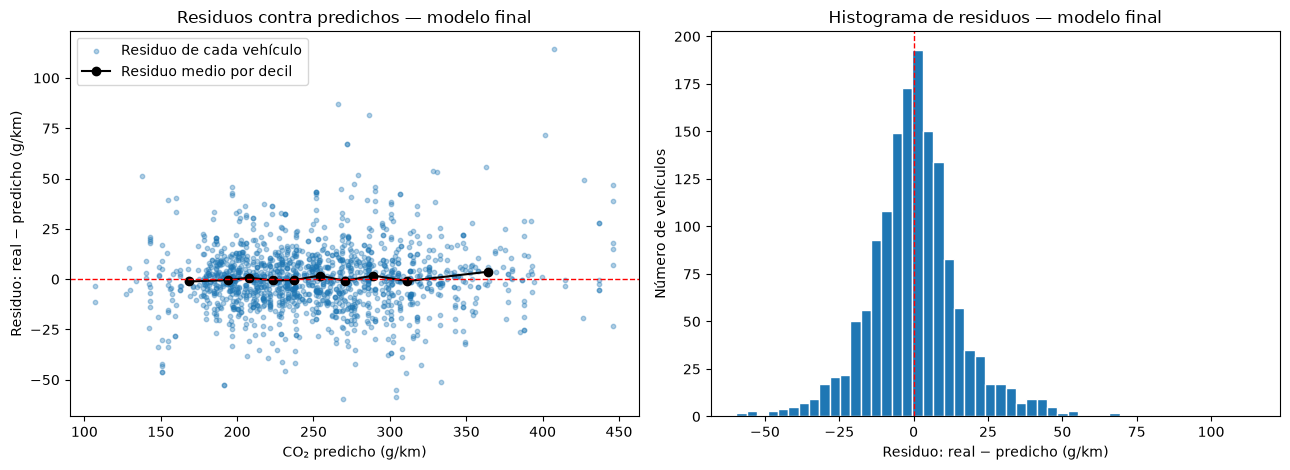

Media = 0.35 | mediana = 0.02 | desviación = 15.91 g/km | asimetría = 0.63 | curtosis (exceso) = 4.19


,pred_medio,res_medio,res_desv,n
"(107.28399999999999, 186.487]",168.62,-1.15,15.50,157
"(186.487, 200.452]",194.16,-0.43,13.48,143
"(200.452, 215.389]",207.70,0.71,13.73,150
"(215.389, 229.624]",223.22,-0.58,13.86,154
"(229.624, 246.235]",237.24,-0.44,12.85,150
"(246.235, 262.176]",254.07,1.80,13.46,146
"(262.176, 277.751]",270.62,-0.84,19.77,149
"(277.751, 300.807]",289.23,1.79,16.66,149
"(300.807, 325.8]",311.37,-0.97,17.61,150
"(325.8, 446.166]",364.40,3.72,19.83,150


In [ ]:
pred_f = pd.Series(pred_test_c["Random Forest"], index=yc_test.index)
res_f = yc_test - pred_f
decil_f = pd.qcut(pred_f, 10)
por_decil_f = pd.DataFrame({"pred": pred_f, "res": res_f}).groupby(decil_f, observed=True).agg(
    pred_medio=("pred", "mean"), res_medio=("res", "mean"), res_desv=("res", "std"), n=("res", "size"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(pred_f, res_f, s=10, alpha=0.35, label="Residuo de cada vehículo")
axes[0].plot(por_decil_f["pred_medio"], por_decil_f["res_medio"], "o-", color="black", label="Residuo medio por decil")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("CO₂ predicho (g/km)"); axes[0].set_ylabel("Residuo: real − predicho (g/km)")
axes[0].set_title("Residuos contra predichos — modelo final"); axes[0].legend()
axes[1].hist(res_f, bins=50, edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residuo: real − predicho (g/km)"); axes[1].set_ylabel("Número de vehículos")
axes[1].set_title("Histograma de residuos — modelo final")
fig.tight_layout()
fig.savefig("figuras/residuos_modelo_final.png", dpi=150)
plt.show()
print(f"Media = {res_f.mean():.2f} | mediana = {res_f.median():.2f} | desviación = {res_f.std():.2f} g/km | "
      f"asimetría = {res_f.skew():.2f} | curtosis (exceso) = {res_f.kurt():.2f}")
por_decil_f.round(2)

**Resultado del tercer intento: corrige V4.2.**

| Random Forest | n prueba | RMSE global (g/km) | R² prueba | RMSE diésel (g/km) | Razón diésel / global | V4.2 (≤ 1,10) |
|---|---|---|---|---|---|---|
| Antes (duplicados exactos) | 1.571 | 15,37 | 0,9334 | 19,06 | 1,2407 | FALLA |
| Después (duplicados normalizados) | 1.498 | 15,91 | 0,9313 | 15,97 | 1,0040 | cumple |

- **Qué había:** 292 filas más eran el mismo vehículo con distinta capitalización. En la partición original, **98 filas de prueba tenían su gemelo en entrenamiento** y 36 filas estaban repetidas dentro de la propia prueba. Entre ellas estaba el "Colorado ZR2 4WD" diésel, cuyo error contaba doble.
- **La disparidad del diésel desaparece:** la razón baja de 1,24 a 1,00, y todos los subgrupos evaluables cumplen el umbral. El que queda más alto es la gasolina premium (Z), con 1,08.
- **El RMSE global sube de 15,37 a 15,91 g/km y el R² baja de 0,9334 a 0,9313.** No significa que el modelo empeoró: el "antes" era **optimista**, porque parte de la prueba eran vehículos que el modelo ya había visto en entrenamiento. El "después" es una estimación más honesta del error con vehículos nuevos. Pasa lo mismo en la regresión lineal (22,28 → 22,80 g/km).
- **Sobreajuste:** el R² de entrenamiento y el de prueba se mantienen cerca (0,9519 frente a 0,9313).
- **Residuos:** el residuo medio por decil sigue cerca de cero (de −1,15 a +3,72 g/km), así que no hay curvatura. La dispersión sigue siendo algo mayor en los deciles altos.
- **El mayor residuo** (+114,5 g/km) es el Bugatti Chiron: 16 cilindros, 522 g/km reales frente a 407,5 predichos. Es el único vehículo de 16 cilindros del dataset, quedó en prueba y está fuera del rango de entrenamiento (máximo 488 g/km). Es un ejemplo de por qué no se debe extrapolar.
- **Advertencia:** los conjuntos de prueba antes y después no son idénticos (1.571 y 1.498 filas), porque la corrección cambia qué filas existen. La comparación es entre dos evaluaciones válidas de cada versión, no sobre las mismas filas.

**Modelo final de la herramienta:** Random Forest (`n_estimators=300`, `random_state=42`) entrenado con los datos corregidos (`pipelines_c["Random Forest"]`).

## 11. Limitaciones (paso 7)

Las cifras de esta sección las calcula la celda siguiente sobre el **modelo final**: Random Forest entrenado con los datos corregidos (sección 10, tercer intento).

In [ ]:
print("Rango de entrenamiento del modelo final")
print(f"  CO2: {yc_train.min()} a {yc_train.max()} g/km (percentiles 1 y 99: {yc_train.quantile(.01):.0f} y {yc_train.quantile(.99):.0f})")
print(f"  Engine Size(L): {Xc_train['Engine Size(L)'].min()} a {Xc_train['Engine Size(L)'].max()}")
print(f"  Cylinders (filas): {Xc_train['Cylinders'].value_counts().sort_index().to_dict()}")
print(f"  Fuel Type (filas): {Xc_train[SUBGRUPO].value_counts().to_dict()}")
print(f"  Vehicle Class con menos filas: {Xc_train['Vehicle Class'].value_counts().tail(5).to_dict()}")
print(f"  Transmission con menos filas: {Xc_train['Transmission'].value_counts().tail(6).to_dict()}")
print(f"Rango de predicciones del modelo final en prueba: {pred_f.min():.1f} a {pred_f.max():.1f} g/km")

print("\nRMSE por tipo de combustible (modelo final, prueba):")
display(rmse_subgrupo_c.loc[("Random Forest", "después")].sort_values("RMSE subgrupo (g/km)", ascending=False).round(2))

g_cls = pd.DataFrame({"res": res_f, "clase": Xc_test["Vehicle Class"]}).groupby("clase")["res"]
print("Clases de vehículo con mayor RMSE (modelo final, prueba):")
display(pd.DataFrame({"n": g_cls.size(), "residuo_medio": g_cls.mean(),
                      "RMSE": g_cls.apply(lambda r: np.sqrt(np.mean(r ** 2)))}).sort_values("RMSE", ascending=False).head(5).round(2))

modelo_c = df_corr.loc[yc_test.index, "Model"]
filas_tec_f = []
for etiqueta in ["HYBRID", "AWD", "4WD", "4X4"]:
    tiene = modelo_c.str.contains(etiqueta, regex=False)
    r = res_f[tiene]
    filas_tec_f.append({"En el nombre del modelo": etiqueta, "n (prueba)": int(tiene.sum()),
                        "residuo_medio": r.mean(), "t": r.mean() / (r.std() / np.sqrt(len(r)))})
print("Sesgo por tecnología no incluida entre las predictoras (modelo final, prueba):")
pd.DataFrame(filas_tec_f).set_index("En el nombre del modelo").round(2)

Rango de entrenamiento del modelo final
  CO2: 99 a 488 g/km (percentiles 1 y 99: 133 y 414)
  Engine Size(L): 0.9 a 8.4
  Cylinders (filas): {3: 58, 4: 1949, 5: 21, 6: 1452, 8: 891, 10: 29, 12: 92}
  Fuel Type (filas): {'X': 2157, 'Z': 1980, 'E': 244, 'D': 110, 'N': 1}
  Vehicle Class con menos filas: {'VAN - PASSENGER': 48, 'SPECIAL PURPOSE VEHICLE': 44, 'MINIVAN': 40, 'STATION WAGON - MID-SIZE': 31, 'VAN - CARGO': 16}
  Transmission con menos filas: {'AS5': 21, 'A10': 21, 'AV10': 7, 'AM5': 3, 'AM9': 1, 'AS4': 1}
Rango de predicciones del modelo final en prueba: 107.3 a 446.2 g/km

RMSE por tipo de combustible (modelo final, prueba):


,n prueba,RMSE subgrupo (g/km),RMSE global (g/km),Razón subgrupo / global,"Cumple ≤ 1,10"
Fuel Type,,,,,
Z,661,17.19,15.91,1.08,True
D,36,15.97,15.91,1.00,True
X,720,15.09,15.91,0.95,True
E,81,11.48,15.91,0.72,True
N,0,NaN,15.91,NaN,no evaluable


Clases de vehículo con mayor RMSE (modelo final, prueba):


,n,residuo_medio,RMSE
clase,,,
TWO-SEATER,84,6.23,20.32
SUV - STANDARD,128,2.06,20.20
MID-SIZE,221,-0.59,18.09
PICKUP TRUCK - SMALL,33,-0.02,17.88
SUV - SMALL,260,-0.63,17.02


Sesgo por tecnología no incluida entre las predictoras (modelo final, prueba):


,n (prueba),residuo_medio,t
En el nombre del modelo,,,
HYBRID,26,-19.70,-5.83
AWD,224,5.06,5.05
4WD,92,4.54,3.12
4X4,72,8.02,4.97


### Limitaciones y condiciones de no uso

Se refieren al **modelo final**: Random Forest con los datos corregidos (sección 10, tercer intento).

**1. Rango con que se entrenó el modelo (no extrapolar fuera de él).**
- **CO₂:** de 99 a 488 g/km. El 98 % central está entre 133 y 414 g/km. Random Forest promedia valores vistos en el entrenamiento, así que **no puede predecir fuera de ese rango**: en prueba sus predicciones van de 107,3 a 446,2 g/km.
- **Ejemplo concreto de extrapolación:** el Bugatti Chiron (16 cilindros, 522 g/km reales) quedó en prueba. El modelo predijo 407,5 g/km, un error de +114,5.
- **Cilindrada:** de 0,9 a 8,4 L.
- **Cilindros:** 3, 4, 5, 6, 8, 10 y 12. **No hay ningún vehículo de 16 cilindros en el entrenamiento**, y hay muy pocas filas de 5 (21) y 10 (29).
- **Categorías:** solo las 16 clases de vehículo, las transmisiones y los tipos de combustible X, Z, E y D presentes en el entrenamiento. Una categoría nueva se codifica como "desconocida" (`handle_unknown="ignore"`), y la estimación pierde la información de esa variable.
- Hay categorías con muy pocas filas de entrenamiento: VAN - CARGO (16), AM9 y AS4 (1 cada una), AM5 (3).

**2. Subgrupos donde el error es mayor** (modelo final, prueba; RMSE global 15,91 g/km).
- **Por combustible, todos cumplen el umbral de 1,10:**
  - Gasolina premium (Z): RMSE 17,19 g/km, razón 1,08. Es la más cercana al límite.
  - Diésel (D): 15,97 g/km, razón 1,00, pero con solo 36 vehículos en prueba; en la partición original llegó a 1,24.
- **Clases de vehículo con más error:** TWO-SEATER (20,32; residuo medio +6,23, subestima), SUV - STANDARD (20,20), MID-SIZE (18,09), PICKUP TRUCK - SMALL (17,88) y SUV - SMALL (17,02).
- **Tecnologías que el modelo no ve:**
  - **Híbridos:** sobreestima su CO₂ en 19,70 g/km (t = −5,83).
  - **Tracción integral:** subestima en 4,5 a 8,0 g/km (AWD +5,06, 4WD +4,54, 4X4 +8,02).
  - **Alto desempeño:** el Bugatti Chiron y otras versiones deportivas aparecen entre los mayores errores (sección 8).
- **Gas natural (N):** su error no se puede evaluar; hay una sola fila y está en entrenamiento.

**3. Variables que podrían cambiar con el tiempo.** El archivo no tiene columna de año del modelo, así que este cambio **no se puede medir** con estos datos.
- **Relación cilindrada–CO₂:** motores más pequeños con turbo o electrificación ligera pueden emitir menos con la misma cilindrada y cilindros. El modelo seguiría estimando con la relación aprendida.
- **Proporción de híbridos y tecnologías de propulsión:** si aumenta, crece el sesgo de sobreestimación de la sección 8.
- **Transmisiones:** los tipos con más marchas (A10, AV10) tienen pocas filas hoy. Transmisiones nuevas llegarían como categorías desconocidas.
- **Mezcla de combustibles y método de ensayo:** si cambia la mezcla de combustibles o el procedimiento oficial con que se mide el consumo, cambia la relación entre las especificaciones y el CO₂ reportado. El modelo tendría que reentrenarse.

**4. Condiciones en las que la herramienta NO debe usarse para decidir.**
- **Como sustituto de la prueba oficial de homologación:** es una estimación previa, no una medición.
- **Cuando la estimación queda cerca del límite de la flota:** a menos de un RMSE, ≈ 16 g/km en general y ≈ 20 g/km en TWO-SEATER y SUV - STANDARD. En esa franja el error típico basta para cambiar la conclusión de "cumple" a "no cumple".
- **En vehículos híbridos, híbridos enchufables o eléctricos, y en gas natural:** no están representados, o el modelo tiene un sesgo sistemático con ellos.
- **En vehículos de tracción integral o de alto desempeño**, sin corregir el sesgo documentado.
- **Fuera de los rangos del punto 1**, o con categorías nuevas o con muy pocas filas de entrenamiento.
- **Para decisiones automáticas sin revisión humana**, o para atribuir causas: las asociaciones del modelo son correlacionales.